## <font color='blue'>Investment Returns</font>
### <font color='blue'>Temporal Fusion Transformers for Predicting Investment Returns</font>

In [1]:
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [2]:
# Imports
import ta
import sklearn
import pandas as pd
import numpy as np
import tensorflow
import yfinance as yf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

## Data Extraction Directly from the Source

https://finance.yahoo.com/

In [5]:
def ret_extract_data(ticker):
    
    # Force 'Adj Close' by setting auto_adjust=False.
    rdata = yf.download(ticker, start = "2000-01-01", end = "2023-12-31", auto_adjust = False)

    # Mapping of original names to lowercase and underscores
    Mapping = {
        'Open':       'open',
        'High':       'high',
        'Low':        'low',
        'Close':      'close',
        'Adj Close':  'adj_close',
        'Volume':     'volume'
    }

    # Applies only to those present in the DataFrame.
    presentes = {col: novo for col, novo in Mapping.items() if col in rdata.columns}
    rdata.rename(columns = presentes, inplace = True)

    # Data como índice
    rdata.index.name = "date"
    
    return rdata

In [6]:
# Extraction of rdata
df = ret_extract_data("MSFT")

[*********************100%***********************]  1 of 1 completed


In [7]:
# Shape
df.shape

(6037, 6)

In [8]:
# first rows
df.head()

Price,adj_close,close,high,low,open,volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
date,,,,,,
2000-01-03,35.443619,58.28125,59.3125,56.00000,58.68750,53228400
2000-01-04,34.246307,56.31250,58.5625,56.12500,56.78125,54119000
2000-01-05,34.607399,56.90625,58.1875,54.68750,55.56250,64059600
2000-01-06,33.448132,55.00000,56.9375,54.18750,56.09375,54976600
2000-01-07,33.885220,55.71875,56.1250,53.65625,54.31250,62013600


In [9]:
# last rows
df.tail()

Price,adj_close,close,high,low,open,volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
date,,,,,,
2023-12-22,367.440765,374.579987,375.179993,372.709991,373.679993,17107500
2023-12-26,367.519318,374.660004,376.940002,373.500000,375.000000,12673100
2023-12-27,366.940552,374.070007,375.059998,372.809998,373.690002,14905400
2023-12-28,368.127411,375.279999,376.459991,374.160004,375.369995,14327000
2023-12-29,368.872955,376.040009,377.160004,373.480011,376.000000,18730800


## Feature Engineering

In [10]:
def ret_func_feature_engineering(df):

    # dataframe copy
    df_copy = df.copy()
    
    # If there is a MultiIndex in the columns, keep only the first level
    if isinstance(df_copy.columns, pd.MultiIndex):
        df_copy.columns = df_copy.columns.get_level_values(0)
    
    # Creates the variable with the return (percentage change in the closing price)

    df_copy["return"] = df_copy["close"].pct_change(1)
    
    # Shift the columns Open, High, Low, Close
    df_copy["op"]  = df_copy["open"].shift(1)
    df_copy["hi"]  = df_copy["high"].shift(1)
    df_copy["lo"]  = df_copy["low"].shift(1)
    df_copy["clo"] = df_copy["close"].shift(1)

    # Shift the Volume column
    df_copy["vol"] = df_copy["volume"].shift(1)
    
    # Simple Moving Average (SMA)
    df_copy["SMA 15"] = df_copy["close"].rolling(15).mean().shift(1)
    df_copy["SMA 60"] = df_copy["close"].rolling(60).mean().shift(1)

    # Moving Standard Deviation (MSD) - Volatilidade
    df_copy["MSD 15"] = df_copy["return"].rolling(15).std().shift(1)
    df_copy["MSD 60"] = df_copy["return"].rolling(60).std().shift(1)
    
    # Volume Weighted Average Price (VWAP)
    vwap = ta.volume.VolumeWeightedAveragePrice(high   = df_copy["high"],
                                                low    = df_copy["low"],
                                                close  = df_copy["close"],
                                                volume = df_copy["volume"],
                                                window = 5)
    
    df_copy["VWAP"] = vwap.vwap.shift(1)
    
    # RSI (now df_copy["close"] is a 1D Series)
    rsi = ta.momentum.RSIIndicator(df_copy["close"], window = 5, fillna = False)
    df_copy["RSI"] = rsi.rsi().shift(1)
    
    return df_copy.dropna()

In [11]:
# Feature engineering
df = ret_func_feature_engineering(df)

In [12]:
df

Price,adj_close,close,high,low,open,volume,return,op,hi,lo,clo,vol,SMA 15,SMA 60,MSD 15,MSD 60,VWAP,RSI
date,,,,,,,,,,,,,,,,,,
2000-03-30,31.433643,51.687500,54.312500,51.250000,53.093750,64178400,-0.035569,52.593750,54.468750,52.562500,53.593750,64363800.0,50.891667,50.815625,0.038358,0.031934,54.201657,60.893094
2000-03-31,32.307861,53.125000,54.125000,52.062500,53.000000,64281400,0.027811,53.093750,54.312500,51.250000,51.687500,64178400.0,51.004167,50.738542,0.038388,0.031966,53.585763,46.533808
2000-04-03,27.632702,45.437500,48.250000,45.000000,47.218750,260118200,-0.144706,53.000000,54.125000,52.062500,53.125000,64281400.0,51.179167,50.675521,0.038895,0.032148,52.790422,56.257046
2000-04-04,26.929543,44.281250,46.000000,42.468750,45.781250,181244400,-0.025447,47.218750,48.250000,45.000000,45.437500,260118200.0,50.941667,50.516146,0.054311,0.036926,49.611815,25.390430
2000-04-05,26.264376,43.187500,44.250000,42.937500,44.125000,82887600,-0.024700,45.781250,46.000000,42.468750,44.281250,181244400.0,50.722917,50.325521,0.054188,0.036985,47.728704,23.016202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,367.440765,374.579987,375.179993,372.709991,373.679993,17107500,0.002784,372.559998,374.410004,370.040009,373.540009,17708000.0,371.795335,352.972669,0.010610,0.013211,371.029851,55.957485
2023-12-26,367.519318,374.660004,376.940002,373.500000,375.000000,12673100,0.000214,373.679993,375.179993,372.709991,374.579987,17107500.0,371.800000,353.988336,0.010216,0.013211,372.476422,59.580089
2023-12-27,366.940552,374.070007,375.059998,372.809998,373.690002,14905400,-0.001575,375.000000,376.940002,373.500000,374.660004,12673100.0,372.167999,354.970169,0.009410,0.013207,373.058235,59.897331


## Pre-processing of rdata

In [13]:
# Training and validation split percentage
split = int(0.85 * len(df))
split_val = int(0.95 * len(df))

In [14]:
df.columns

Index(['adj_close', 'close', 'high', 'low', 'open', 'volume', 'return', 'op',
       'hi', 'lo', 'clo', 'vol', 'SMA 15', 'SMA 60', 'MSD 15', 'MSD 60',
       'VWAP', 'RSI'],
      dtype='object', name='Price')

In [20]:
# Training dataset
x_training = df[['VWAP','RSI','SMA 15','SMA 60','MSD 15','MSD 60','op','hi','lo','clo','vol']].iloc[:split,:]
y_training = df[['return']].iloc[:split,:]

In [21]:
# Validation dataset
x_valid = df[['VWAP','RSI','SMA 15','SMA 60','MSD 15','MSD 60','op','hi','lo','clo','vol']].iloc[split:split_val,:]
y_valid = df[['return']].iloc[split:split_val,:]

In [22]:
# Test dataset
x_test = df[['VWAP','RSI','SMA 15','SMA 60','MSD 15','MSD 60','op','hi','lo','clo','vol']].iloc[split_val:,:]
y_test = df[['return']].iloc[split_val:,:]

### Standardization

In [23]:
# create a StandardScaler object
sc = StandardScaler()

In [24]:
# Fit e transform in the training data
x_training_sc = sc.fit_transform(x_training)

In [25]:
# Transform nos rdata de validação
x_valid_sc = sc.transform(x_valid)

In [26]:
# Transform nos rdata de teste
x_test_sc = sc.transform(x_test)

## Adjustment to the rdata format

In [27]:
x_training

Price,VWAP,RSI,SMA 15,SMA 60,MSD 15,MSD 60,op,hi,lo,clo,vol
date,,,,,,,,,,,
2000-03-30,54.201657,60.893094,50.891667,50.815625,0.038358,0.031934,52.593750,54.468750,52.562500,53.593750,64363800.0
2000-03-31,53.585763,46.533808,51.004167,50.738542,0.038388,0.031966,53.093750,54.312500,51.250000,51.687500,64178400.0
2000-04-03,52.790422,56.257046,51.179167,50.675521,0.038895,0.032148,53.000000,54.125000,52.062500,53.125000,64281400.0
2000-04-04,49.611815,25.390430,50.941667,50.516146,0.054311,0.036926,47.218750,48.250000,45.000000,45.437500,260118200.0
2000-04-05,47.728704,23.016202,50.722917,50.325521,0.054188,0.036985,45.781250,46.000000,42.468750,44.281250,181244400.0
...,...,...,...,...,...,...,...,...,...,...,...
2020-06-02,182.002271,52.051215,182.979333,167.693000,0.011101,0.043753,182.539993,183.000000,181.460007,182.830002,22622400.0
2020-06-03,182.096349,66.789606,182.857333,168.082000,0.011118,0.043579,184.250000,185.000000,181.350006,184.910004,30794600.0
2020-06-04,183.090688,69.338338,183.047334,168.661000,0.009303,0.042572,184.820007,185.940002,183.580002,185.360001,27311000.0


In [28]:
x_training_sc

array([[ 0.28234306,  0.42380325,  0.18781321, ...,  0.24671724,
         0.26071236,  0.30086637],
       [ 0.26384156, -0.31101364,  0.1912202 , ...,  0.20705   ,
         0.2037284 ,  0.29497362],
       [ 0.23994947,  0.18655982,  0.19651996, ...,  0.23160591,
         0.24669991,  0.29824737],
       ...,
       [ 4.15417528,  0.85597705,  4.19006279, ...,  4.2064143 ,
         4.19963047, -0.87682002],
       [ 4.16503397, -0.35816589,  4.19646288, ...,  4.16772933,
         4.12669093, -0.83070778],
       [ 4.18949152,  0.83487808,  4.20992932, ...,  4.1589645 ,
         4.2546339 , -0.47689459]])

In [29]:
# Function to adjust the rdata format
def ret_format_rdata(X_s, y_s, lag):

    if len(X_s) != len(y_s):
        print("Warnings")

    X_train = []

    for variable in range(0, X_s.shape[1]):
        
        X = []

        for i in range(lag, X_s.shape[0]):
            X.append(X_s[i-lag:i, variable])

        X_train.append(X)
    
    # Converts X_train to a NumPy array and adjusts the axes
    X_train, np.array(X_train)
    X_train = np.swapaxes(np.swapaxes(X_train, 0, 1), 1, 2)

    # Initializes the y_train list.
    y_train = []
    
    # Creates the list of labels adjusted according to 'lag'
    for i in range(lag, y_s.shape[0]):
        y_train.append(y_s[i, :].reshape(-1,1).transpose())
    
    # Converts y_train to a NumPy array and adjusts the axes
    y_train = np.concatenate(y_train, axis = 0)
    
    # Returns X_train and y_train adjusted
    return X_train, y_train

In [30]:
# Lag Value
lag = 15

In [32]:
# Adjusting the training rdata format
x_train_final, y_train_final = ret_format_rdata(x_training_sc, y_training.values, lag)

In [33]:
# Applies the function to the validation rdata
x_valid_final, y_valid_final = ret_format_rdata(x_valid_sc, y_valid.values, lag)

In [34]:
# Applies the function to the test rdata
x_test_final, y_test_final = ret_format_rdata(x_test_sc, y_test.values, lag)

In [35]:
print(f"Shape of the training data: {x_train_final.shape}")
print(f"Shape of the validation data: {x_valid_final.shape}")
print(f"Shape of the test data: {x_test_final.shape}")

Shape of the training data: (5064, 15, 11)
Shape of the validation data: (583, 15, 11)
Shape of the test data: (284, 15, 11)


In [36]:
x_train_final

array([[[ 2.82343062e-01,  4.23803255e-01,  1.87813208e-01, ...,
          2.46717235e-01,  2.60712355e-01,  3.00866375e-01],
        [ 2.63841560e-01, -3.11013636e-01,  1.91220199e-01, ...,
          2.07049997e-01,  2.03728396e-01,  2.94973620e-01],
        [ 2.39949475e-01,  1.86559817e-01,  1.96519961e-01, ...,
          2.31605907e-01,  2.46699906e-01,  2.98247373e-01],
        ...,
        [-1.41049800e-01, -2.07226198e+00,  2.83155879e-02, ...,
         -2.34956366e-01, -2.33460013e-01,  3.06143437e+00],
        [-1.67386778e-01, -1.53616601e+00, -1.39090405e-04, ...,
         -2.38734198e-01, -2.07303442e-01,  2.06196725e+00],
        [-1.75794926e-01, -4.06171416e-01, -2.41142074e-02, ...,
         -1.95289128e-01, -1.37241197e-01,  1.17272707e+00]],

       [[ 2.63841560e-01, -3.11013636e-01,  1.91220199e-01, ...,
          2.07049997e-01,  2.03728396e-01,  2.94973620e-01],
        [ 2.39949475e-01,  1.86559817e-01,  1.96519961e-01, ...,
          2.31605907e-01,  2.46699906e

## Construction of the Temporal Fusion Transformer Model

https://arxiv.org/abs/1912.09363

In [37]:
# Function of the Transformer encoder
def ret_transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout = 0):
    
    # Normalizes inputs using normalization layers
    x = layers.LayerNormalization(epsilon = 1e-6)(inputs)
    
    # Applies multi-head attention to the inputs
    x = layers.MultiHeadAttention(key_dim = head_size, num_heads = num_heads, dropout = dropout)(x, x, x)
    
    # Applies Dropout to the output of the attention layer
    x = layers.Dropout(dropout)(x)
    
    # Adds the initial inputs as a residual connection
    res = x + inputs

    # Normalizes the sum of the residual connection
    x = layers.LayerNormalization(epsilon = 1e-6)(res)
    
    # Applies a convolutional layer with ReLU activation
    x = layers.Conv1D(filters = ff_dim, kernel_size = 1, activation = "relu")(x)
    
    # Applies Dropout after the convolutional layer
    x = layers.Dropout(dropout)(x)
    
    # Applies a second convolutional layer
    x = layers.Conv1D(filters = inputs.shape[-1], kernel_size = 1)(x)
    
    # Returns the sum of the second convolutional layer and the residual connection
    return x + res

The function below is used to build the final model using LSTM, GRU, and Transformer.

In [38]:
# Model creation function
def ret_create_model(input_shape, 
                    head_size, 
                    num_heads, 
                    ff_dim, 
                    num_transformer_blocks, 
                    mlp_units, 
                    dropout = 0, 
                    mlp_dropout = 0):
    
    # Defines the input layer with the specified shape
    inputs = keras.Input(shape = input_shape)
    
    # Initializes the model input in the variable x
    x = inputs
    
    # Adds an LSTM layer with 10 units and returns sequences
    x = layers.LSTM(10, return_sequences = True)(x)
    
    # Adds transformer blocks to the model
    for _ in range(num_transformer_blocks):
        x = ret_transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    
    # Adds a GRU layer with 100 units and does not return sequences
    x = layers.GRU(100, return_sequences = False)(x)
    
    # Adds a Dropout layer with the specified rate
    x = layers.Dropout(mlp_dropout)(x)
    
    # Adds a Dense layer with the specified units and ReLU activation
    x = layers.Dense(mlp_units, activation = "relu")(x)
    
    # Defines the output layer with 1 unit (model output)
    outputs = layers.Dense(1)(x)
    
    # Returns the created model with the specified inputs and outputs
    return keras.Model(inputs, outputs)

In [39]:
input_shape = x_train_final.shape[1:]

In [40]:
# Creates the model
model_ret = ret_create_model(input_shape,
                             head_size = 16,
                             num_heads = 1,
                             ff_dim = 4,
                             num_transformer_blocks = 1,
                             mlp_units = 125,
                             dropout = 0.1,
                             mlp_dropout = 0.25)

In [41]:
# Compiles the model
model_ret.compile(loss = "mean_squared_error", optimizer = keras.optimizers.Adam())

In [42]:
model_ret.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 15, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 15, 10)    │        880 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 15, 10)    │         20 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 10)    │        698 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 15, 10)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 10)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 10)    │         20 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 15, 4)     │         44 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 15, 4)     │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 15, 10)    │         50 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 15, 10)    │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 100)       │     33,600 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 100)       │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 125)       │     12,625 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        126 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,063 (187.75 KB)

 Trainable params: 48,063 (187.75 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Callbacks
callbacks = [keras.callbacks.EarlyStopping(patience = 5, restore_best_weights = True)]

## Model Training and Evaluation

In [44]:
%%time

model_ret.fit(x_train_final,
               y_train_final,
               validation_data = (x_valid_final, y_valid_final),
               epochs = 20,
               batch_size = 64,
               callbacks = callbacks)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0043 - val_loss: 3.9703e-04
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.1333e-04 - val_loss: 3.2132e-04
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.9185e-04 - val_loss: 5.3454e-04
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6112e-04 - val_loss: 4.3846e-04
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.4788e-04 - val_loss: 3.3621e-04
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0571e-04 - val_loss: 4.1096e-04
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.4445e-04 - val_loss: 3.2671e-04
CPU times: user 7.65 s, sys: 3.16 s, total: 10.8 s
Wall time: 8.15 s


<Axes: >

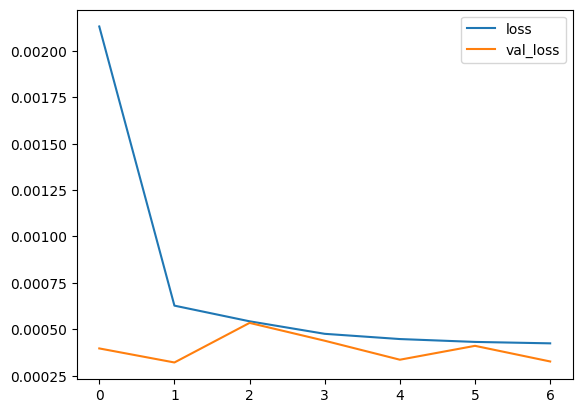

In [45]:
# Plot
pd.DataFrame(model_ret.history.history).plot()

In [46]:
# Predictions
pred = model_ret.predict(x_test_final)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [47]:
# Calculate the score
score = np.sqrt(metrics.mean_squared_error(pred, y_test_final))

In [48]:
print("Score (RMSE): {}".format(score))

Score (RMSE): 0.016138932691977494


## Prediction and Return Calculation

The line of code below performs the following operation:

- It generates predictions for the input `x_train_final`. This prediction returns a NumPy array.

- It creates a NumPy array of zeros with dimensions `[lag, 1]`. The `lag` variable is typically an integer representing a time lag or delay (for example, if you are working with time series and want to consider the 5 previous values, the lag would be 5).

- It then concatenates the array of zeros with the model's predictions along axis 0 (i.e., vertically). The reason for this is to adjust the shape of the data; since a lag shift was introduced when creating the input data for the model, you now need to fill in those initial points in the output data.

In [49]:
y_pred_train = np.concatenate((np.zeros([lag,1]), model_ret.predict(x_train_final)), axis = 0)

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [51]:
y_pred_valid = np.concatenate((np.zeros([lag,1]), model_ret.predict(x_valid_final)), axis = 0)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [52]:
y_pred_test = np.concatenate((np.zeros([lag,1]), model_ret.predict(x_test_final)), axis = 0)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [53]:
# Concatenates the training, validation, and test predictions into a final prediction.
df["prediction"] = np.concatenate((y_pred_train, y_pred_valid, y_pred_test), axis = 0)

In [54]:
df.tail()

Price,adj_close,close,high,low,open,volume,return,op,hi,lo,clo,vol,SMA 15,SMA 60,MSD 15,MSD 60,VWAP,RSI,prediction
date,,,,,,,,,,,,,,,,,,,
2023-12-22,367.440765,374.579987,375.179993,372.709991,373.679993,17107500,0.002784,372.559998,374.410004,370.040009,373.540009,17708000.0,371.795335,352.972669,0.010610,0.013211,371.029851,55.957485,0.002854
2023-12-26,367.519318,374.660004,376.940002,373.500000,375.000000,12673100,0.000214,373.679993,375.179993,372.709991,374.579987,17107500.0,371.800000,353.988336,0.010216,0.013211,372.476422,59.580089,0.002897
2023-12-27,366.940552,374.070007,375.059998,372.809998,373.690002,14905400,-0.001575,375.000000,376.940002,373.500000,374.660004,12673100.0,372.167999,354.970169,0.009410,0.013207,373.058235,59.897331,0.003012
2023-12-28,368.127411,375.279999,376.459991,374.160004,375.369995,14327000,0.003235,373.690002,375.059998,372.809998,374.070007,14905400.0,372.271334,355.841336,0.009152,0.013046,373.431023,55.856718,0.003022
2023-12-29,368.872955,376.040009,377.160004,373.480011,376.000000,18730800,0.002025,375.369995,376.459991,374.160004,375.279999,14327000.0,372.703335,356.872836,0.008715,0.012489,374.135986,62.365107,0.002934


In [56]:
# Calculates the strategy
df["ret_strategy"] = df["return"] * np.sign(df["prediction"].shift(1))

In [57]:
df.tail()

Price,adj_close,close,high,low,open,volume,return,op,hi,lo,clo,vol,SMA 15,SMA 60,MSD 15,MSD 60,VWAP,RSI,prediction,ret_strategy
date,,,,,,,,,,,,,,,,,,,,
2023-12-22,367.440765,374.579987,375.179993,372.709991,373.679993,17107500,0.002784,372.559998,374.410004,370.040009,373.540009,17708000.0,371.795335,352.972669,0.010610,0.013211,371.029851,55.957485,0.002854,0.002784
2023-12-26,367.519318,374.660004,376.940002,373.500000,375.000000,12673100,0.000214,373.679993,375.179993,372.709991,374.579987,17107500.0,371.800000,353.988336,0.010216,0.013211,372.476422,59.580089,0.002897,0.000214
2023-12-27,366.940552,374.070007,375.059998,372.809998,373.690002,14905400,-0.001575,375.000000,376.940002,373.500000,374.660004,12673100.0,372.167999,354.970169,0.009410,0.013207,373.058235,59.897331,0.003012,-0.001575
2023-12-28,368.127411,375.279999,376.459991,374.160004,375.369995,14327000,0.003235,373.690002,375.059998,372.809998,374.070007,14905400.0,372.271334,355.841336,0.009152,0.013046,373.431023,55.856718,0.003022,0.003235
2023-12-29,368.872955,376.040009,377.160004,373.480011,376.000000,18730800,0.002025,375.369995,376.459991,374.160004,375.279999,14327000.0,372.703335,356.872836,0.008715,0.012489,374.135986,62.365107,0.002934,0.002025


### ret_strategy
The strategy here is that if the previous day's forecast was positive, you take a long position (buy) and your return is simply the asset's return. If the previous day's forecast was negative, you take a short position (sell), and your return is the negative of the asset's return (because when you short-sell an asset, you make money when the price falls).
It is a trading strategy based on the previous day's forecasts.
This strategy assumes that you can perfectly predict end-of-day values ​​based on the previous day's forecasts.

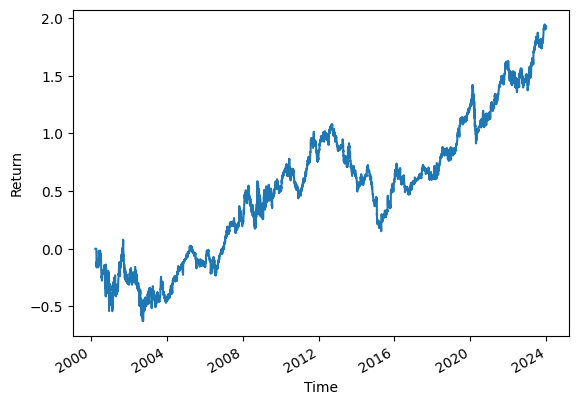

In [59]:
# Cumulative plot
df["ret_strategy"].iloc[:].cumsum().plot()

plt.xlabel("Time")  
plt.ylabel("Return")  

plt.show()